# Training

## 1. Load data

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

from analyse.analyse import (evaluer_auc, importance_permutation, tableau_tranches, tracer_importances)
from cible import (VARIABLES_MODELE, ajouter_eloignee, ajuster_modele_decision, cible_individuelle,
                   coefficients, entrainer_modele_cible, octroi_top_k, score_merite)

In [2]:
def ajouter_attributs(df, reference):
    """Ajoute la cote R relative a la region et au revenu (medianes calculees sur `reference`).

    - cote_r_rel_a_region : cote R / mediane de la cote R dans la region du dossier ;
    - cote_r_rel_au_revenu : cote R / mediane de la cote R dans la tranche de revenu du dossier
      (15 tranches de meme effectif dans `reference`).
    Les medianes et les bornes viennent de `reference` : les candidats sont mesures avec la meme
    definition que l'historique.
    """
    mediane_region = reference.groupby('region_administrative')['cote_r_equivalent'].median()
    _, bornes = pd.qcut(reference['revenu_familial_estime'], q=15, retbins=True)
    bornes[0], bornes[-1] = -np.inf, np.inf
    tranche = lambda d: pd.cut(d['revenu_familial_estime'], bornes, labels=False)
    mediane_revenu = reference['cote_r_equivalent'].groupby(tranche(reference)).median()

    df.insert(0, 'cote_r_rel_au_revenu', df['cote_r_equivalent'] / tranche(df).map(mediane_revenu))
    df.insert(0, 'cote_r_rel_a_region',
              df['cote_r_equivalent'] / df['region_administrative'].map(mediane_region))


demandes = pd.read_csv('data/donnees_demandes.csv')
groupe_hist = np.where(ajouter_eloignee(demandes)['eloignee'] == 1, 'Eloignee', 'Centre')
ajouter_attributs(demandes, reference=demandes.copy())
print(f'{len(demandes)} dossiers historiques')

10000 dossiers historiques


In [3]:
demandes.info()
print()
print(demandes.describe(include='all').T[['count', 'unique', 'top', 'mean']])

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   cote_r_rel_a_region                10000 non-null  float64
 1   cote_r_rel_au_revenu               10000 non-null  float64
 2   id_candidat                        10000 non-null  str    
 3   cote_r_equivalent                  10000 non-null  float64
 4   programme_etudes                   10000 non-null  str    
 5   region_administrative              10000 non-null  str    
 6   code_postal_3                      10000 non-null  str    
 7   revenu_familial_estime             10000 non-null  int64  
 8   heures_travail_semaine             10000 non-null  int64  
 9   distance_domicile_campus_km        10000 non-null  float64
 10  premiere_generation_universitaire  10000 non-null  int64  
 11  decision_octroi                    10000 non-null  int64  
dtypes:

In [4]:
# La cible n'est pas decision_octroi, biaisee, mais la cible individuelle (cible.cible_individuelle).
# Elle se construit a partir d'un modele de decision du comite (regression logistique avec la region) :
# - evaluation : modele de decision ajuste sur train seulement (cellule 12), pour eviter toute fuite ;
# - modele final : modele de decision ajuste sur tout l'historique (section Prediction).
# decision_octroi et la region restent donc dans `demandes` : elles servent a construire la cible.
print('Taux d\'octroi du comite par groupe :',
      demandes['decision_octroi'].groupby(groupe_hist).mean().round(3).to_dict())

Taux d'octroi du comite par groupe : {'Centre': 0.484, 'Eloignee': 0.273}


## 2. Prepare features

In [5]:
# Variables du modele : celles de cible.VARIABLES_MODELE (ni la region ni le code postal, ni la distance
# ni le revenu, dont la cible a retire l'effet), plus la cote R relative a la region et au revenu.
NOUVELLES_VARIABLES = ['cote_r_rel_a_region', 'cote_r_rel_au_revenu']
VARIABLES = VARIABLES_MODELE + NOUVELLES_VARIABLES
CATEGORIELLES = ['programme_etudes']
print('Variables du modele :', VARIABLES)

Variables du modele : ['cote_r_equivalent', 'heures_travail_semaine', 'premiere_generation_universitaire', 'programme_etudes', 'cote_r_rel_a_region', 'cote_r_rel_au_revenu']


In [6]:
for col in VARIABLES + ['decision_octroi', 'region_administrative']:
    if col not in demandes.columns:
        raise ValueError(f"Colonne {col} manquante dans les données d'entrée.")

In [7]:
# Meme decoupage que la baseline et model_corrige.ipynb (stratifie sur la decision du comite).
train, test = train_test_split(
    demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi']
)

In [8]:
def preparer(df):
    """Variables du modele, dans l'ordre attendu par le pipeline."""
    return df[VARIABLES]

In [9]:
# Modele de decision du comite ajuste sur train seulement.
modele_valid = ajuster_modele_decision(train)

X_train, X_test = preparer(train), preparer(test)
# y_train : cible individuelle souple. y_test : reference de merite binarisee (40 % meilleurs scores).
y_train = cible_individuelle(modele_valid, train)
y_test = octroi_top_k(score_merite(modele_valid, test, reference=train))
print('Moyenne de y_train par groupe :', pd.Series(y_train).groupby(groupe_hist[train.index]).mean().round(3).to_dict())

Moyenne de y_train par groupe : {'Centre': 0.484, 'Eloignee': 0.447}


## 3. Training (fit)

In [10]:
modele = entrainer_modele_cible(train, y_train, new_features=NOUVELLES_VARIABLES)
proba_test = modele.predict_proba(X_test)[:, 1]
y_pred = octroi_top_k(proba_test, taux=0.40)   # budget : 40 % d'octroi

# AUC ponderee contre la cible souple de test (ajustement du modele).
cible_te = cible_individuelle(modele_valid, test, reference=train)
n = len(test)
auc = roc_auc_score(np.r_[np.ones(n), np.zeros(n)], np.r_[proba_test, proba_test],
                    sample_weight=np.r_[cible_te, 1 - cible_te])
print(f'AUC contre la cible individuelle : {auc:.3f}')
print(f'Exactitude contre la reference de merite : {accuracy_score(y_test, y_pred):.2%}')
print()
print(classification_report(y_test, y_pred, digits=3))

AUC contre la cible individuelle : 0.947
Exactitude contre la reference de merite : 95.07%

              precision    recall  f1-score   support

           0      0.959     0.959     0.959      1800
           1      0.938     0.938     0.938      1200

    accuracy                          0.951      3000
   macro avg      0.949     0.949     0.949      3000
weighted avg      0.951     0.951     0.951      3000



## 4. Evaluation

### metrics

In [11]:
from cible import ELOIGNEES


def groupe_region(df):
    """Regroupe les cinq regions en deux blocs : grands centres / regions eloignees."""
    return np.where(df['region_administrative'].isin(ELOIGNEES), 'Eloignee', 'Centre')

In [12]:
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    selection_rate,
    true_positive_rate,
)

groupe_test = groupe_hist[test.index]

cadre = MetricFrame(
    metrics={
        'exactitude': accuracy_score,
        'taux_selection': selection_rate,
        'taux_vrais_positifs': true_positive_rate,
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=groupe_test,
)
print(cadre.by_group.round(4))

ecart_parite = demographic_parity_difference(y_test, y_pred, sensitive_features=groupe_test)
print(f'\nEcart de parite demographique : {ecart_parite:.4f}')

                     exactitude  taux_selection  taux_vrais_positifs
sensitive_feature_0                                                 
Centre                   0.9425          0.4045               0.9196
Eloignee                 0.9624          0.3935               0.9678

Ecart de parite demographique : 0.0110


In [13]:
# AUC contre la reference de merite binarisee, globale et par groupe.
print(evaluer_auc(modele, X_test, y_test, groupes=groupe_test).round(4))

global      0.9920
Centre      0.9899
Eloignee    0.9957
Name: auc, dtype: float64


### Confusion matrix

In [14]:
for g in ['Centre', 'Eloignee']:
    masque = groupe_test == g
    matrice = pd.DataFrame(confusion_matrix(y_test[masque], y_pred[masque]),
                           index=['merite 0', 'merite 1'], columns=['predit 0', 'predit 1'])
    print(f'--- {g} ---')
    print(matrice, end='\n\n')

--- Centre ---
          predit 0  predit 1
merite 0       998        43
merite 1        59       675

--- Eloignee ---
          predit 0  predit 1
merite 0       728        31
merite 1        15       451



### Feature importance

num__cote_r_equivalent                     5.296
num__cote_r_rel_au_revenu                 -1.460
num__heures_travail_semaine                0.638
cat__programme_etudes_Arts et lettres     -0.096
num__premiere_generation_universitaire    -0.084
cat__programme_etudes_Sciences sociales   -0.083
num__cote_r_rel_a_region                  -0.068
cat__programme_etudes_Sciences             0.037
cat__programme_etudes_Sante                0.033
cat__programme_etudes_Genie               -0.003
Name: coefficient standardise, dtype: float64



                                   moyenne  ecart_type
cote_r_equivalent                   0.6050      0.0039
cote_r_rel_au_revenu                0.0221      0.0023
heures_travail_semaine              0.0159      0.0010
premiere_generation_universitaire   0.0004      0.0001
cote_r_rel_a_region                 0.0002      0.0001
programme_etudes                    0.0001      0.0001


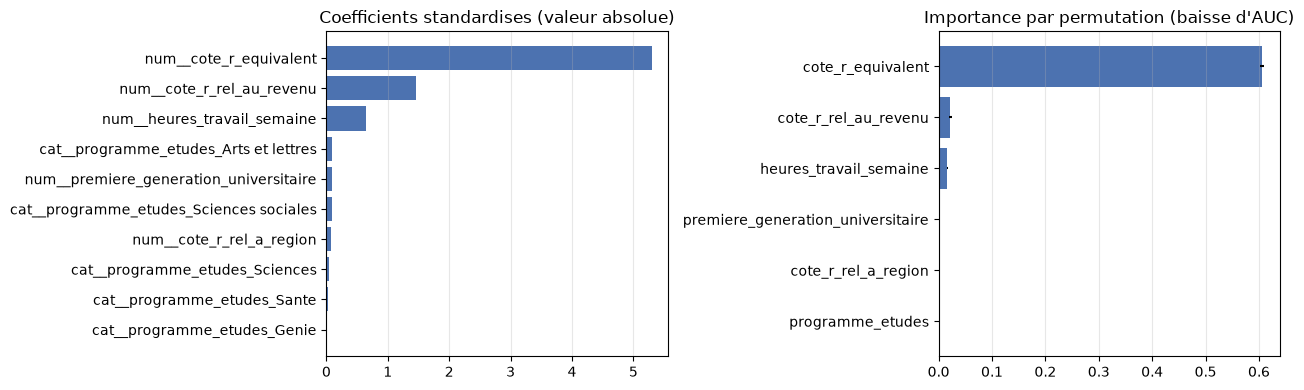

In [15]:
# Regression logistique : coefficients standardises, puis importance par permutation (baisse d'AUC).
coefs = coefficients(modele).rename('coefficient standardise')
print(coefs.round(3))
imp_perm = importance_permutation(modele, X_test, y_test)
print()
print(imp_perm.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
tracer_importances(coefs.abs().sort_values(ascending=False), 'Coefficients standardises (valeur absolue)', ax=axes[0])
tracer_importances(imp_perm, 'Importance par permutation (baisse d\'AUC)', ax=axes[1])
plt.tight_layout()
plt.show()

### By slice

In [16]:
# Metriques par tranche contre la reference de merite (voir analyse_slices.ipynb pour le detail).
g_te = pd.Series(groupe_test, index=test.index, name='groupe')
bornes_revenu = np.quantile(train['revenu_familial_estime'], [0.2, 0.4, 0.6, 0.8])   # quintiles de train
tranches = {
    'region': test['region_administrative'].rename('region'),
    'cote R': pd.concat([pd.cut(test['cote_r_equivalent'], [0, 26, 27, 28, 29, 30, 32, 45]).astype(str)
                         .rename('cote R'), g_te], axis=1),
    'revenu': pd.concat([pd.cut(test['revenu_familial_estime'], np.r_[-np.inf, bornes_revenu, np.inf],
                                labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5']).astype(str).rename('revenu'), g_te], axis=1),
}
for nom, tranche in tranches.items():
    print(f'--- {nom} ---')
    print(tableau_tranches(y_test, y_pred, tranche, complet=True).round(3), end='\n\n')

--- region ---
                               effectif  meritants  taux_selection    tpr  \
region                                                                      
Bas-Saint-Laurent                 400.0      147.0           0.370  0.973   
Capitale-Nationale                611.0      256.0           0.408  0.895   
Cote-Nord                         364.0      136.0           0.398  0.949   
Gaspesie-Iles-de-la-Madeleine     461.0      183.0           0.410  0.978   
Montreal                         1164.0      478.0           0.403  0.933   

                                 fpr  precision  exactitude  
region                                                       
Bas-Saint-Laurent              0.020      0.966       0.978  
Capitale-Nationale             0.056      0.920       0.923  
Cote-Nord                      0.070      0.890       0.937  
Gaspesie-Iles-de-la-Madeleine  0.036      0.947       0.970  
Montreal                       0.034      0.951       0.953  

--- cote R

# Prediction

In [17]:
candidats = pd.read_csv('data/candidats_evaluation.csv')
groupe_cand = np.where(ajouter_eloignee(candidats)['eloignee'] == 1, 'Eloignee', 'Centre')
ajouter_attributs(candidats, reference=demandes)

# Modele final : modele de decision et cible sur tout l'historique, puis modele entraine sur cette cible.
modele_decision = ajuster_modele_decision(demandes)
modele_final = entrainer_modele_cible(demandes, cible_individuelle(modele_decision, demandes),
                                      new_features=NOUVELLES_VARIABLES)
X_cand = preparer(candidats)

In [18]:
predictions = octroi_top_k(modele_final.predict_proba(X_cand)[:, 1], taux=0.40)

soumission = pd.DataFrame({
    'id_candidat': candidats['id_candidat'],
    'decision_octroi': predictions.astype(int),
})
assert len(soumission) == 4000 and soumission['id_candidat'].is_unique
assert set(soumission['decision_octroi']) <= {0, 1}
taux = soumission['decision_octroi'].mean()
assert 0.36 <= taux <= 0.44, f'Hors budget : {taux:.1%}'

soumission.to_csv('predictions.csv', index=False)
print(f'{len(soumission)} lignes ecrites dans predictions.csv, taux d\'octroi {taux:.1%}')
print(soumission.groupby(groupe_cand)['decision_octroi'].mean().round(3).to_dict())

4000 lignes ecrites dans predictions.csv, taux d'octroi 40.0%
{'Centre': 0.403, 'Eloignee': 0.395}
